# Visualization & Geovisualization in Python

**Author:** Alexander Michels

This notebook will walk you through the basics of visualization and geovisualization in Python.

<p style='color:red;'><b>Text in red indicates tasks to perform.</b></p>

## Table of Contents:

* [Matplotlib](#matplotlib)
* [Geopandas & Folium](#geopandas)
* [Contextily](#contextily)
* [Gifs with Imageio](#gifs)
* [Recap and Deliverables](#recap)

<hr id="matplotlib">

## Matplotlib

Matplotlib is a a comprehensive library for visualizing data in Python. There are many other packages that have different specialties (e.g., big data, spatial data, etc.), but many packages use Matplotlib as a foundation.

Most of the work we will do is in the Pyplot portion of the package which we will import as `plt'.

Run the cell below to generate a basic plot:

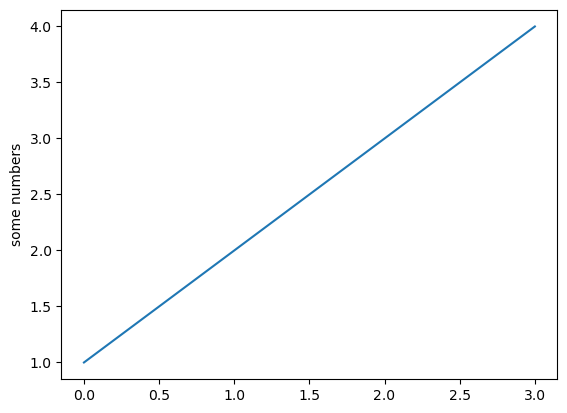

In [1]:
import matplotlib.pyplot as plt

plt.plot([1, 2, 3, 4])
plt.ylabel('some numbers')
plt.show()

Some useful links as you work with Matplotlib:

* [Pyplot Tutorial](https://matplotlib.org/stable/tutorials/pyplot.html#sphx-glr-tutorials-pyplot-py)
* [Matplotlib Quick Start](https://matplotlib.org/stable/users/explain/quick_start.html)

<p style='color:red;'><b>Create any plot with Matplotlib with red dash markers, a title, and both x- and y-axis labels. Set the x-label to your first name and the y-label to your last name. Copy, save, or screenshot the figure and post it into a document with your lab deliverables.</b></p>

<hr id="geopandas" />

## Geopandas

Geopandas is an open source Python package for interacting with spatial data. It is built on top of the popular `Pandas` package for working with `DataFrames` (think of these as spreadsheets) so it has all of the functionalities of Pandas plus some spatial capabilities.

In [2]:
import geopandas as gpd

/tmp/ipykernel_317/3841419929.py:1: DeprecationWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas still uses PyGEOS by default. However, starting with version 0.14, the default will switch to Shapely. To force to use Shapely 2.0 now, you can either uninstall PyGEOS or set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In the next release, GeoPandas will switch to using Shapely by default, even if PyGEOS is installed. If you only have PyGEOS installed to get speed-ups, this switch should be smooth. However, if you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


We will use the [CDC/ATSDR Social Vulnerability Index (CDC/ATSDR SVI or SVI)](https://www.atsdr.cdc.gov/place-health/php/svi/svi-data-documentation-download.html) dataset to explore Geopandas.

In [3]:
gdf = gpd.read_file("data/Texas.gdb")  # gdf is the variable we will save our geodataframe as
gdf.head()  # look at the top 5 rows of our gdf

,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE,Shape_Length,Shape_Area,geometry
0,48,Texas,TX,48001,Anderson County,48001950100,Census Tract 9501; Anderson County; Texas,186.605650,5268,742,...,0.1,0.0,0.9,9.0,5.3,0.0,0.1,1.085318,0.046861,"MULTIPOLYGON (((-95.69483 31.97972, -95.69343 ..."
1,48,Texas,TX,48001,Anderson County,48001950401,Census Tract 9504.01; Anderson County; Texas,6.374261,4763,108,...,1.0,0.0,1.0,5.2,4.4,0.1,0.2,0.230634,0.001596,"MULTIPOLYGON (((-95.84761 31.75934, -95.84660 ..."
2,48,Texas,TX,48001,Anderson County,48001950402,Census Tract 9504.02; Anderson County; Texas,27.465086,6540,110,...,0.4,0.0,0.8,2.7,1.2,0.0,0.8,0.588650,0.007024,"MULTIPOLYGON (((-95.98345 31.78998, -95.98172 ..."
3,48,Texas,TX,48001,Anderson County,48001950500,Census Tract 9505; Anderson County; Texas,8.931332,4323,638,...,1.1,0.8,1.2,2.9,2.4,1.2,1.6,0.263611,0.002211,"MULTIPOLYGON (((-95.68778 31.81046, -95.68202 ..."
4,48,Texas,TX,48001,Anderson County,48001950600,Census Tract 9506; Anderson County; Texas,7.974505,5448,784,...,0.9,0.0,0.9,0.6,1.2,0.0,0.9,0.272369,0.001999,"MULTIPOLYGON (((-95.70784 31.72538, -95.70396 ..."


The geopandas `plot` method of GeoDataFrames can be used to create static maps. [Documentation on plot](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html).

<Axes: >

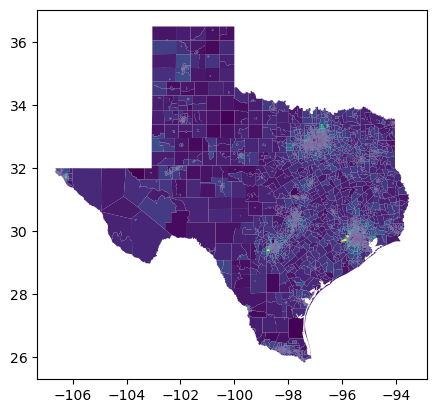

In [4]:
gdf.plot(column="E_TOTPOP")

The geopandas `explore` method of GeoDataFrames can be used to quickly visualize geospatial data in interactive HTML maps. [Documentation on `explore`](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.explore.html)

In [5]:
gdf.loc[0:10].explore(column="E_TOTPOP")

The `explore` function creates maps using the Python [`folium`](https://python-visualization.github.io/folium/latest/getting_started.html) package. 

We can check the type of a variable by calling the `type()` function on it. This is a core functionality of Python and can be used with any package.

In [6]:
type(gdf.explore(column="E_TOTPOP"))

folium.folium.Map

Because Geopandas uses Folium, all of the documentation around Folium will work with our `explore` function including the save function (see the Folium Quick Start for more info!)

In [7]:
m = gdf.explore(column="E_TOTPOP")
m.save("index.html")

The save function saves the folium map to a file called "index.html" within the same working directory as our Jupyter notebook. We can open the file by double clicking it, pulling up the map!

Using the SVI and Geopandas documentation, perform the following tasks:

* <p style='color:red;'><b>In a few sentences, answer: what does the `E_TOTPOP` variable represent, and how was it measured?.</b> (HINT: documentation is useful, this data comes from the CDC SVI.)</p>
* <p style='color:red;'><b>Using the CDC SVI data for Texas, create a static map (not an interactive HTML one) of the "Persons below 150% poverty estimate, 2018-2022 ACS" and using a non-default colormap. Copy, save, or screenshot the figure and post it into a document with your lab deliverables along with an explanation of how you performed the task and why you chose the colormap you did.</b></p>
* <p style='color:red;'><b>In a few sentences, describe how an interactive HTML map---like the ones created by `explore` and folium---could be useful for data science tasks and at least one advantage over a static map (e.g., the ones created by `plot`).</b></p>
* <p style='color:red;'><b>Using the CDC SVI data for Texas, create an HTML map (not a static image) of the "Persons below 150% poverty estimate, 2018-2022 ACS" and using a non-default colormap. Screenshot the map and post it into a document with your lab deliverables along with an explanation of how you performed the task and why you chose the colormap you did.</b></p>

<hr id="contextily" />

## Contextily

You may be dismayed by the blank white backgrounds of Geopandas plots. Fortunately, there is a solution to that as well! The Python [`contextily`](https://contextily.readthedocs.io/en/latest/) package can provide basemaps for our maps!

In [8]:
import contextily as cx

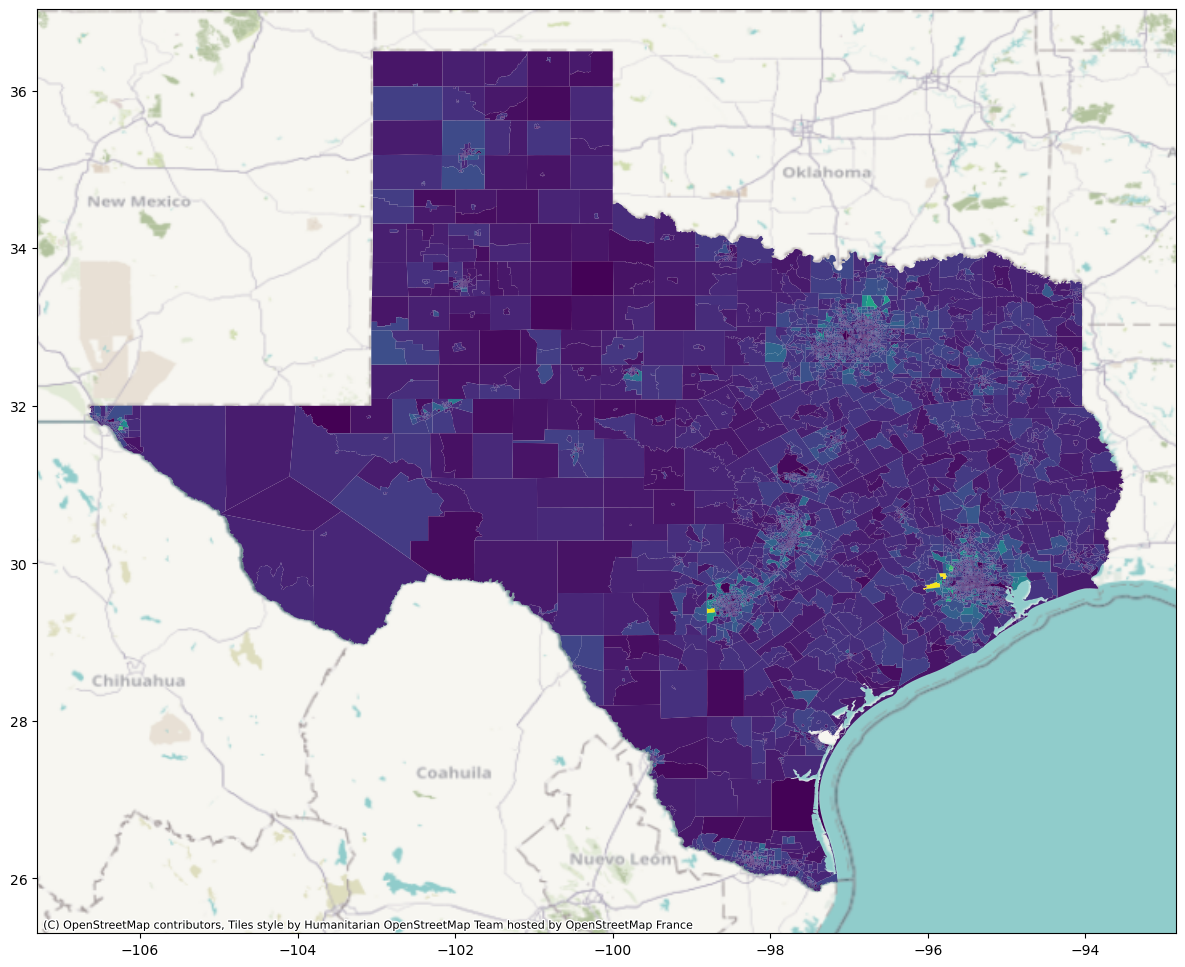

In [9]:
# using the same geodataframe from above
ax = gdf.plot(column="E_TOTPOP", figsize=(18,12))  # save the Matplotlib axis of the plot
cx.add_basemap(ax, crs=gdf.crs)  # add the basemap to the axis using the GeoDataFrame's Coordinate Reference System (CRS)

* <p style='color:red;'><b>Explore the `contextily` documentation <a href="https://contextily.readthedocs.io/en/latest/intro_guide.html">https://contextily.readthedocs.io/en/latest/intro_guide.html</a> and choose a different basemap (Note: some basemaps may require API keys, skip those). What basemap did you choose and what kind of data visualizations/maps may pair well with this basemap?</b></p>

* <p style='color:red;'><b>Create a map of the "Persons below 150% poverty estimate, 2018-2022 ACS" with this basemap and paste it into your lab document.</b></p>

<hr id="gifs" />

## Gifs with Imageio

Movies and gifs are created by displaying multiple images in quick succession. So if we create multiple images that are designed to be shown one after another, we can use the `imageio` package to create a gif. 

In [10]:
x = gdf[gdf["FIPS"] == "48001950100"]  # select the rows from our GeoDataFrame such that the "FIPS" field is equal to the code
x = x.to_crs("EPSG:3083")  # project to Texas Centric Albers Equal Area https://epsg.io/3083
x

,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE,Shape_Length,Shape_Area,geometry
0,48,Texas,TX,48001,Anderson County,48001950100,Census Tract 9501; Anderson County; Texas,186.60565,5268,742,...,0.1,0.0,0.9,9.0,5.3,0.0,0.1,1.085318,0.046861,"MULTIPOLYGON (((1905956.186 7547822.606, 19060..."


An example gif: 

* In a "for" loop we will continually increase the buffer around our Census Tract and save the figure at each step.

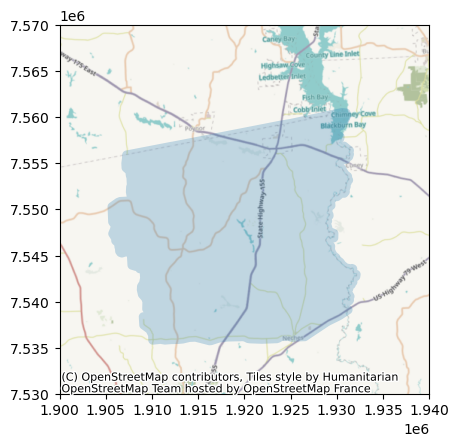

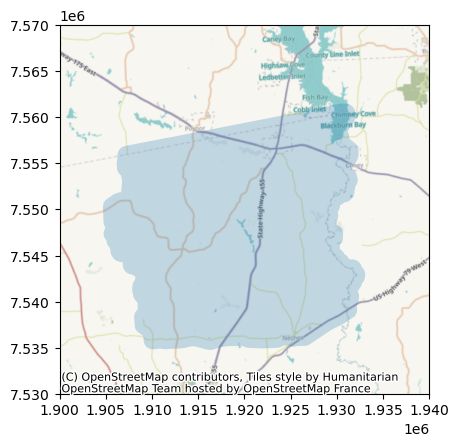

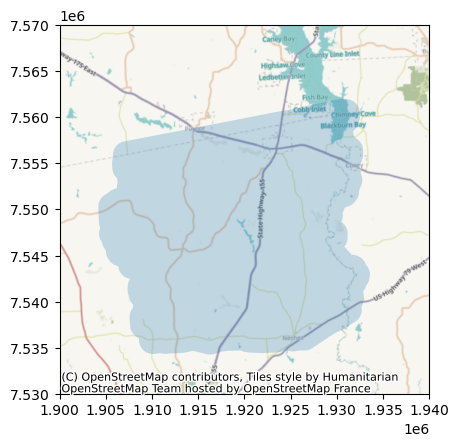

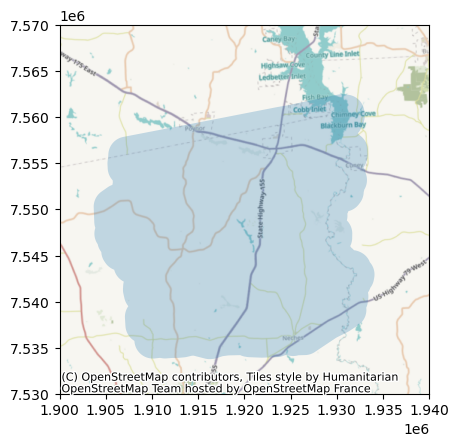

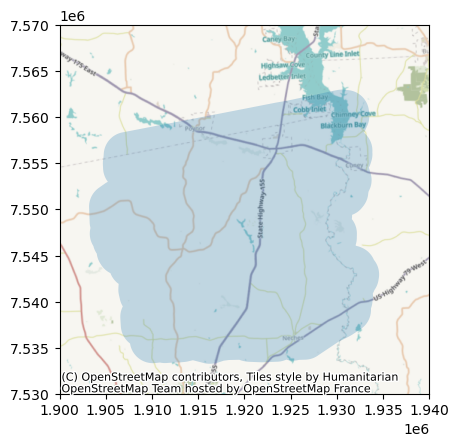

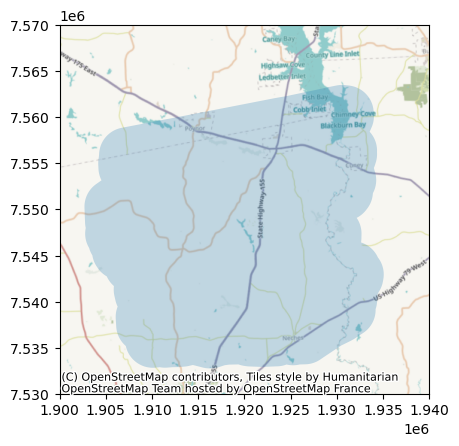

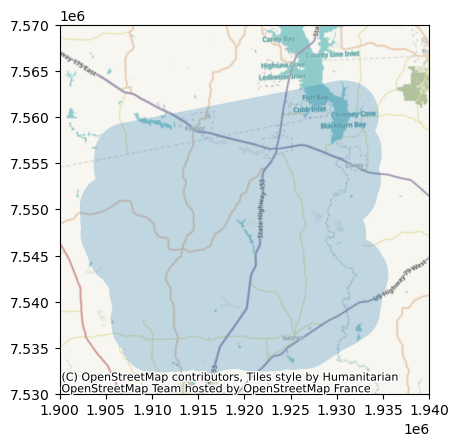

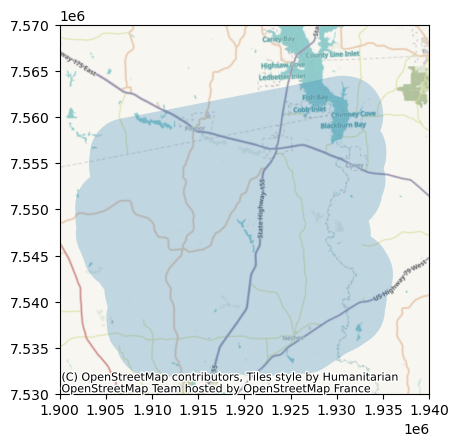

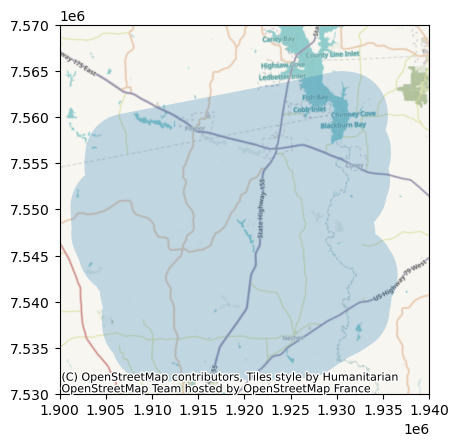

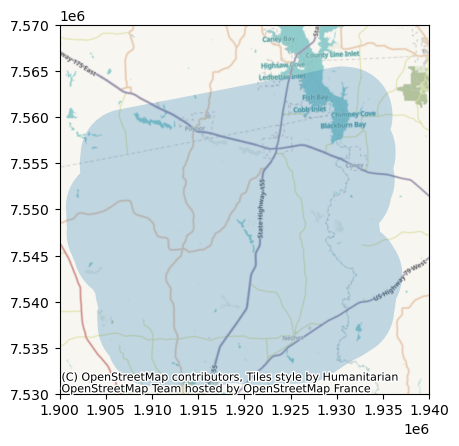

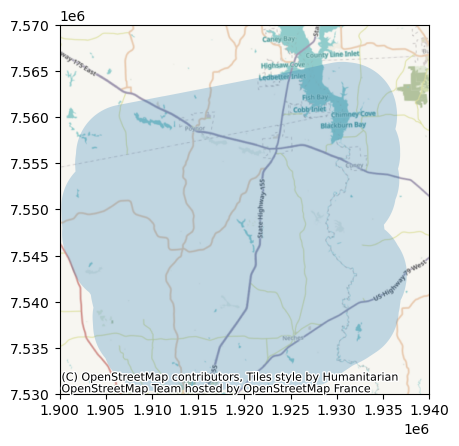

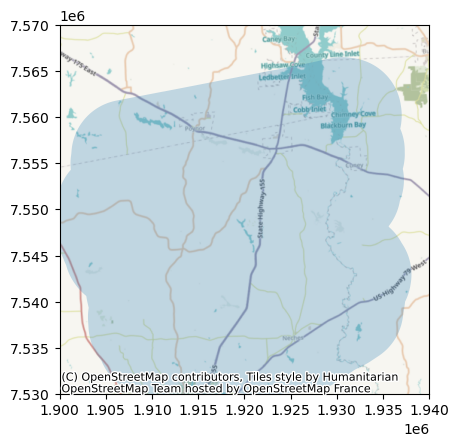

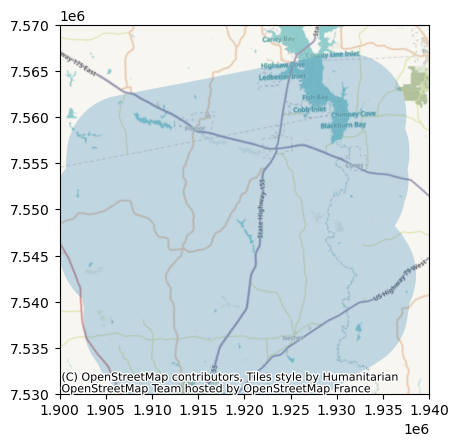

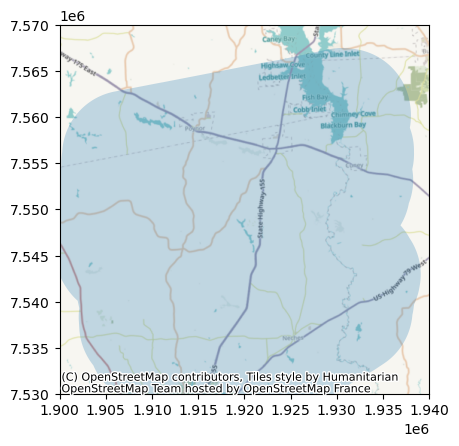

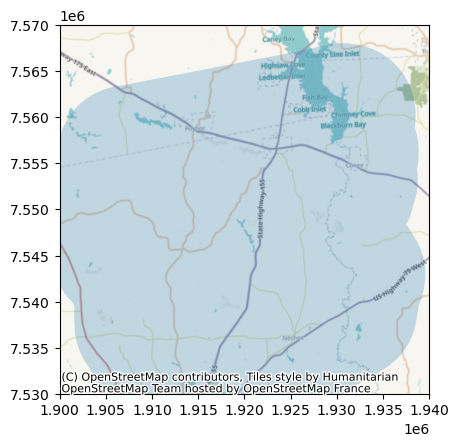

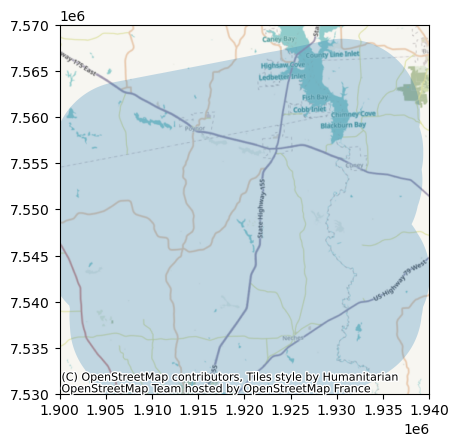

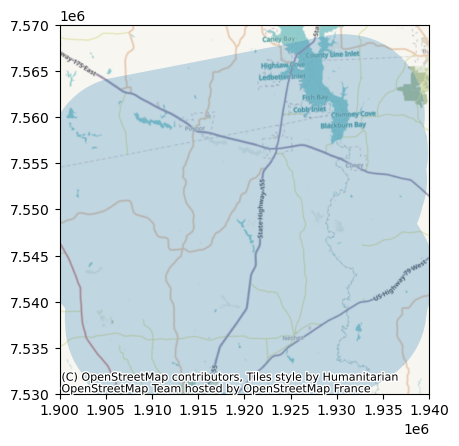

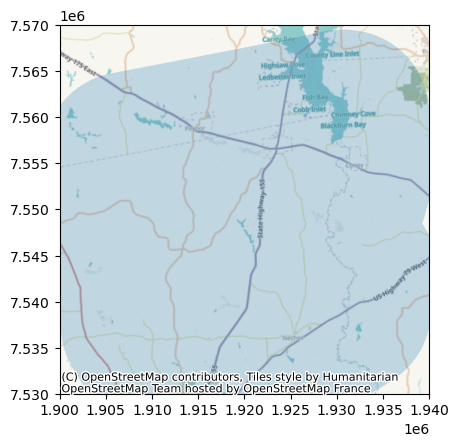

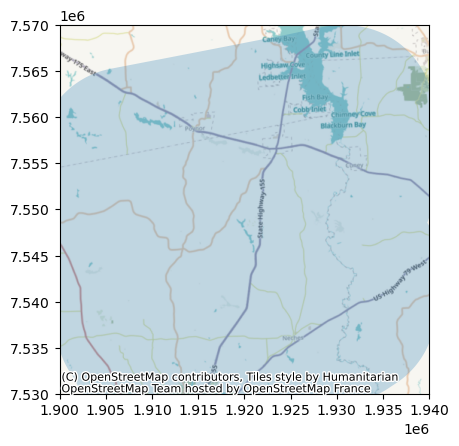

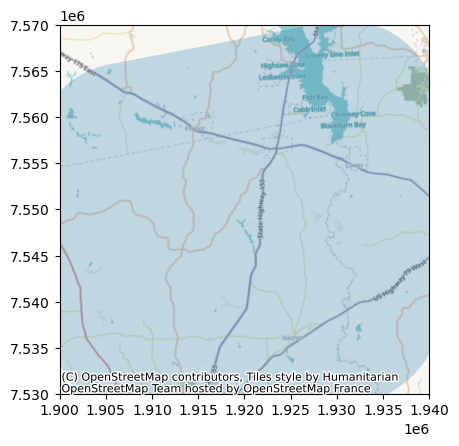

In [11]:
for i in range(20):  # using the variable i from 0 to 19 (we stop at 20)
    x.geometry = x.geometry.buffer(500)  # units in meters, so tenth of a kilometer
    ax = x.plot(alpha=0.25)  # alpha controls the transparencysource=cx.providers.CartoDB.Voyager
    plt.axis([1900000, 1940000, 7530000, 7570000])  # setting the x and y bounds on the figure to remain consistent
    cx.add_basemap(ax, crs=x.crs)
    plt.savefig(f"Image{i}.png")  # using Pyplot save the current figure to a filename "Image{i}.png" where {i} will be replaced by the value of i (f-strings)

Example code for creating gifs and other use-cases on their documentation page: https://imageio.readthedocs.io/en/stable/examples.html#optimizing-a-gif-using-pygifsicle

In [12]:
import imageio.v3 as iio
import numpy as np  # numpy is an array package and images are just arrays of numbers!

# here we are using a list comprehension which allows us to do a for loop in a single line to create an array!
frames = np.stack([iio.imread(f"Image{x}.png") for x in range(20)])

iio.imwrite("movie.gif", frames, loop=0)

You can now open the file "movie.gif" to see your gif or the cell below should load it when run:

![A gif of the Census tract expanding](movie.gif "Y our gif of a census tract expanding")

* <p style='color:red;'><b>What are some possible use-cases of a GIF for spatial visualization? Explain a specific use-case and why a GIF (as opposed to a map) is well-suited to visualize the data.</b></p>

<hr id="recap" />

## Recap and Deliverables

Create a document and enter/paste the answers to the below questions into it to turn in.

* <p style='color:red;'><b>Create any plot with Matplotlib with red dash markers, a title, and both x- and y-axis labels. Set the x-label to your first name and the y-label to your last name. Copy, save, or screenshot the figure and post it into a document with your lab deliverables.</b></p>
* <p style='color:red;'><b>In a few sentences, answer: what does the `E_TOTPOP` variable represent, and how was it measured?.</b></p>
* <p style='color:red;'><b>Using the CDC SVI data for Texas, create a static map (not an interactive HTML one) of the "Persons below 150% poverty estimate, 2018-2022 ACS" and using a non-default colormap. Copy, save, or screenshot the figure and post it into a document with your lab deliverables along with an explanation of how you performed the task and why you chose the colormap you did.</b></p>
* <p style='color:red;'><b>In a few sentences, describe how an interactive HTML map---like the ones created by `explore` and folium---could be useful for data science tasks and at least one advantage over a static map (e.g., the ones created by `plot`).</b></p>
* <p style='color:red;'><b>Using the CDC SVI data for Texas, create an HTML map (not a static image) of the "Persons below 150% poverty estimate, 2018-2022 ACS" and using a non-default colormap. Screenshot the map and post it into a document with your lab deliverables along with an explanation of how you performed the task and why you chose the colormap you did.</b></p>
* <p style='color:red;'><b>Explore the `contextily` documentation <a href="https://contextily.readthedocs.io/en/latest/intro_guide.html">https://contextily.readthedocs.io/en/latest/intro_guide.html</a> and choose a different basemap (Note: some basemaps may require API keys, skip those). What basemap did you choose and what kind of data visualizations/maps may pair well with this basemap?</b></p>
* <p style='color:red;'><b>Create a map of the "Persons below 150% poverty estimate, 2018-2022 ACS" with this basemap and paste it into your lab document.</b></p>
* <p style='color:red;'><b>What are some possible use-cases of a GIF for spatial visualization? Explain a specific use-case and why a GIF (as opposed to a map) is well-suited to visualize the data.</b></p>